**Download and merge new data sources**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

!pip install yfinance pandas-datareader -q

import yfinance as yf
import pandas_datareader as pdr

# ============================================================
# STEP 1: Load existing merged data
# ============================================================
merged = pd.read_csv("/content/drive/MyDrive/datasets/merged_monthly_data.csv",
                     parse_dates=['month'])

for col in ['oil', 'gas', 'inflation', 'product']:
    merged[col] = merged[col].astype(str).str.replace(',', '', regex=False)
    merged[col] = pd.to_numeric(merged[col], errors='coerce')

merged = merged.sort_values('month').reset_index(drop=True)

# ============================================================
# STEP 2: Download new features
# ============================================================
START = '2013-01-01'
END   = '2023-12-31'

# --- USD/CNY ---
try:
    usdcny = pdr.get_data_fred('DEXCHUS', start=START, end=END)
    usdcny = usdcny.resample('MS').mean()
    usdcny.columns = ['usdcny']
    usdcny.index.name = 'month'
    usdcny = usdcny.reset_index()
    usdcny['month'] = pd.to_datetime(usdcny['month']).dt.to_period('M').dt.to_timestamp()
    print("USD/CNY ✓  rows:", len(usdcny))
except Exception as e:
    print("USD/CNY failed:", e)
    usdcny = None

# --- Naphtha ---
try:
    naph = yf.download("BZ=F", start=START, end=END, interval="1mo", progress=False)
    if isinstance(naph.columns, pd.MultiIndex):
        naph.columns = naph.columns.get_level_values(0)
    naph = naph[['Close']].rename(columns={'Close': 'naphtha'})
    naph.index = pd.to_datetime(naph.index).to_period('M').to_timestamp()
    naph.index.name = 'month'
    naph = naph.reset_index()
    naph['month'] = pd.to_datetime(naph['month']).dt.to_period('M').dt.to_timestamp()
    print("Naphtha ✓  rows:", len(naph))
except Exception as e:
    print("Naphtha failed:", e)
    naph = None

# --- Copper ---
try:
    copper = yf.download("HG=F", start=START, end=END, interval="1mo", progress=False)
    if isinstance(copper.columns, pd.MultiIndex):
        copper.columns = copper.columns.get_level_values(0)
    copper = copper[['Close']].rename(columns={'Close': 'copper'})
    copper.index = pd.to_datetime(copper.index).to_period('M').to_timestamp()
    copper.index.name = 'month'
    copper = copper.reset_index()
    copper['month'] = pd.to_datetime(copper['month']).dt.to_period('M').dt.to_timestamp()
    print("Copper ✓  rows:", len(copper))
except Exception as e:
    print("Copper failed:", e)
    copper = None

# --- BDI from Investing.com ---
try:
    bdi = pd.read_csv("/content/drive/MyDrive/datasets/BDIY.csv")
    bdi.columns = bdi.columns.str.strip()
    bdi = bdi[['Date', 'Price']].rename(columns={'Date': 'month', 'Price': 'bdi'})
    bdi['bdi'] = bdi['bdi'].astype(str).str.replace(',', '', regex=False)
    bdi['bdi'] = pd.to_numeric(bdi['bdi'], errors='coerce')
    bdi['month'] = pd.to_datetime(bdi['month'], dayfirst=False).dt.to_period('M').dt.to_timestamp()
    bdi = bdi.groupby('month').mean().reset_index()
    bdi = bdi[(bdi['month'] >= pd.Timestamp(START)) &
              (bdi['month'] <= pd.Timestamp(END))]
    print("BDI ✓  rows:", len(bdi))
except Exception as e:
    print("BDI failed:", e)
    bdi = None

# --- LLDPE from Investing.com ---
try:
    lldpe = pd.read_csv("/content/drive/MyDrive/datasets/lldpe.csv")
    lldpe.columns = lldpe.columns.str.strip()
    print("LLDPE raw columns:", lldpe.columns.tolist())
    print(lldpe.head(2))

    # handle both possible Investing.com formats
    if 'Price' in lldpe.columns:
        lldpe = lldpe[['Date', 'Price']].rename(columns={'Date': 'month', 'Price': 'lldpe'})
    elif 'Close' in lldpe.columns:
        lldpe = lldpe[['Date', 'Close']].rename(columns={'Date': 'month', 'Close': 'lldpe'})
    else:
        # use second column as price if column names are different
        lldpe.columns.values[0] = 'month'
        lldpe.columns.values[1] = 'lldpe'
        lldpe = lldpe[['month', 'lldpe']]

    lldpe['lldpe'] = lldpe['lldpe'].astype(str).str.replace(',', '', regex=False)
    lldpe['lldpe'] = pd.to_numeric(lldpe['lldpe'], errors='coerce')
    lldpe['month'] = pd.to_datetime(lldpe['month'], dayfirst=False).dt.to_period('M').dt.to_timestamp()
    lldpe = lldpe.groupby('month').mean().reset_index()
    lldpe = lldpe[(lldpe['month'] >= pd.Timestamp(START)) &
                  (lldpe['month'] <= pd.Timestamp(END))]
    print("LLDPE ✓  rows:", len(lldpe))
except Exception as e:
    print("LLDPE failed:", e)
    lldpe = None

# ============================================================
# STEP 3: Merge all features
# ============================================================
merged['month'] = pd.to_datetime(merged['month']).dt.to_period('M').dt.to_timestamp()

if usdcny is not None:
    merged = merged.merge(usdcny, on='month', how='left')

if naph is not None:
    merged = merged.merge(naph, on='month', how='left')

if copper is not None:
    merged = merged.merge(copper, on='month', how='left')

if bdi is not None:
    merged = merged.merge(bdi, on='month', how='left')

if lldpe is not None:
    merged = merged.merge(lldpe, on='month', how='left')

# --- fill missing values ---
for col in ['usdcny', 'naphtha', 'copper', 'bdi', 'lldpe']:
    if col in merged.columns:
        merged[col] = merged[col].ffill().bfill()

print("\nColumns:", merged.columns.tolist())
print("Shape:", merged.shape)
print("Missing values:\n", merged.isnull().sum())

USD/CNY ✓  rows: 132
Naphtha ✓  rows: 113
Copper ✓  rows: 113
BDI ✓  rows: 132
LLDPE raw columns: ['Date', 'Price', 'Open', 'High', 'Low', 'Vol.', 'Change %']
         Date     Price      Open      High       Low   Vol. Change %
0  03/01/2025  8,072.00  8,124.00  8,150.00  8,013.00  0.04K   -0.68%
1  02/01/2025  8,127.00  7,843.00  8,150.00  7,810.00  0.51K    3.62%
LLDPE ✓  rows: 132

Columns: ['month', 'oil', 'gas', 'inflation', 'product', 'usdcny', 'naphtha', 'copper', 'bdi', 'lldpe']
Shape: (119, 10)
Missing values:
 month        0
oil          0
gas          0
inflation    0
product      0
usdcny       0
naphtha      0
copper       0
bdi          0
lldpe        0
dtype: int64


** Feature engineering + train/test split**

In [ ]:
# ============================================================
# STEP 4: Feature engineering
# ============================================================
new_cols = [c for c in ['usdcny', 'naphtha', 'copper', 'bdi', 'lldpe'] if c in merged.columns]
print("New features available:", new_cols)

# --- propylene proxy (naphtha - oil spread) ---
merged['propylene_proxy'] = merged['naphtha'] - merged['oil']
print("Propylene proxy ✓")

# --- all columns to engineer features from ---
feature_cols = ['oil', 'gas', 'inflation', 'usdcny',
                'naphtha', 'copper', 'bdi', 'lldpe', 'propylene_proxy']

merged['product_diff'] = merged['product'].diff()

for col in feature_cols:
    merged[f'{col}_diff'] = merged[col].diff()
    for lag in [1, 2, 3]:
        merged[f'{col}_lag{lag}']      = merged[col].shift(lag)
        merged[f'{col}_diff_lag{lag}'] = merged[f'{col}_diff'].shift(lag)
    merged[f'{col}_roll3'] = merged[col].rolling(3).mean()
    merged[f'{col}_roll6'] = merged[col].rolling(6).mean()

for lag in [1, 2, 3]:
    merged[f'product_diff_lag{lag}'] = merged['product_diff'].shift(lag)

merged['month_num'] = merged['month'].dt.month
merged['year']      = merged['month'].dt.year

merged = merged.dropna().reset_index(drop=True)
print("Shape after feature engineering:", merged.shape)

# ============================================================
# STEP 5: Define X and y
# ============================================================
drop_cols = ['month', 'product', 'product_diff',
             'product_diff_lag1', 'product_diff_lag2', 'product_diff_lag3']

features = [c for c in merged.columns if c not in drop_cols]
X = merged[features]
y = merged['product']

print(f"Total features: {len(features)}")

# ============================================================
# STEP 6: Chronological train/test split
# ============================================================
split_date   = '2022-01-01'
train_idx    = merged['month'] < split_date
test_idx     = merged['month'] >= split_date
test_indices = merged[test_idx].index.tolist()

actual_prices = merged.loc[test_idx, 'product'].values
test_dates    = merged.loc[test_idx, 'month'].values

print(f"Train: {train_idx.sum()} rows | Test: {test_idx.sum()} rows")
print("جاهز ✓")

New features available: ['usdcny', 'naphtha', 'copper', 'bdi', 'lldpe']
Propylene proxy ✓
Shape after feature engineering: (114, 98)
Total features: 92
Train: 90 rows | Test: 24 rows
جاهز ✓


**Optuna + final model**

Using best parameters from R²=0.80 run

=== Final Model ===
MAE        = 178.6 CNY/ton
RMSE       = 226.6 CNY/ton
R²         = 0.8009
MAPE       = 2.30%
Coverage   = 87.5%  (target ~90%)
Avg width  = 1296 CNY/ton


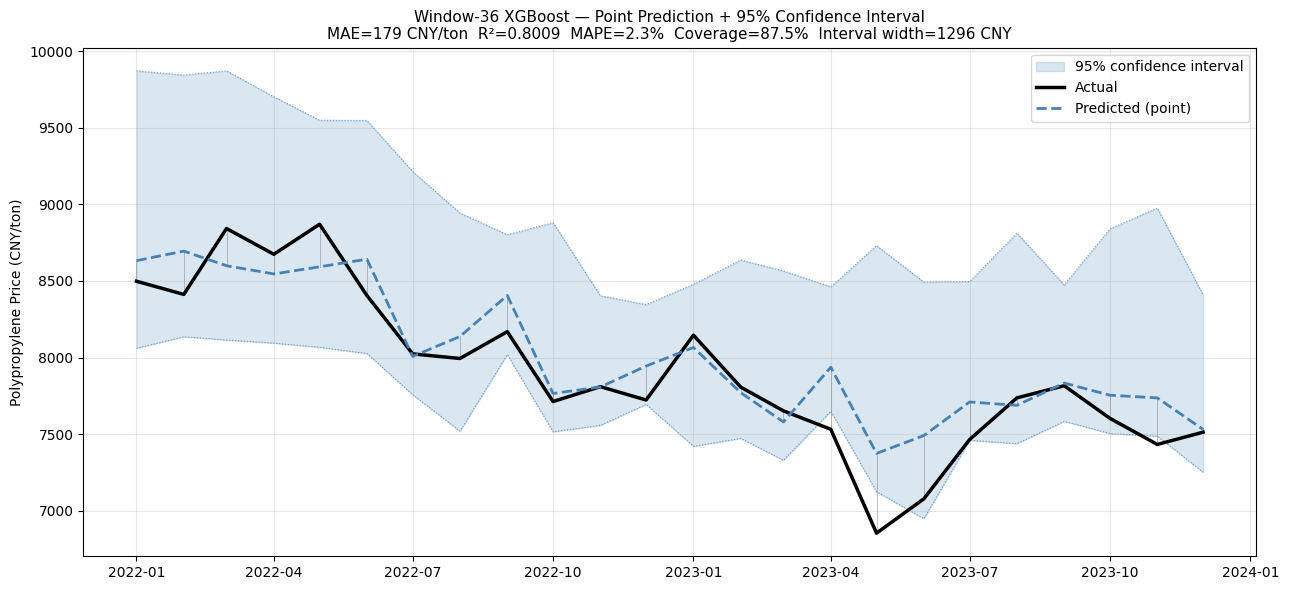


=== Monthly Predictions with Confidence Intervals ===
     month  actual  predicted  lower_95  upper_95  error  error_%  inside_band
2022-01-01  8498.0     8632.0    8060.0    9871.0  134.0      1.6         True
2022-02-01  8412.0     8695.0    8136.0    9844.0  283.0      3.4         True
2022-03-01  8842.0     8599.0    8115.0    9871.0 -243.0     -2.7         True
2022-04-01  8674.0     8546.0    8094.0    9702.0 -128.0     -1.5         True
2022-05-01  8870.0     8592.0    8067.0    9549.0 -278.0     -3.1         True
2022-06-01  8405.0     8642.0    8027.0    9548.0  237.0      2.8         True
2022-07-01  8024.0     8007.0    7757.0    9214.0  -17.0     -0.2         True
2022-08-01  7994.0     8137.0    7520.0    8942.0  143.0      1.8         True
2022-09-01  8169.0     8405.0    8019.0    8802.0  236.0      2.9         True
2022-10-01  7713.0     7765.0    7515.0    8880.0   52.0      0.7         True
2022-11-01  7810.0     7808.0    7558.0    8403.0   -2.0     -0.0         Tr

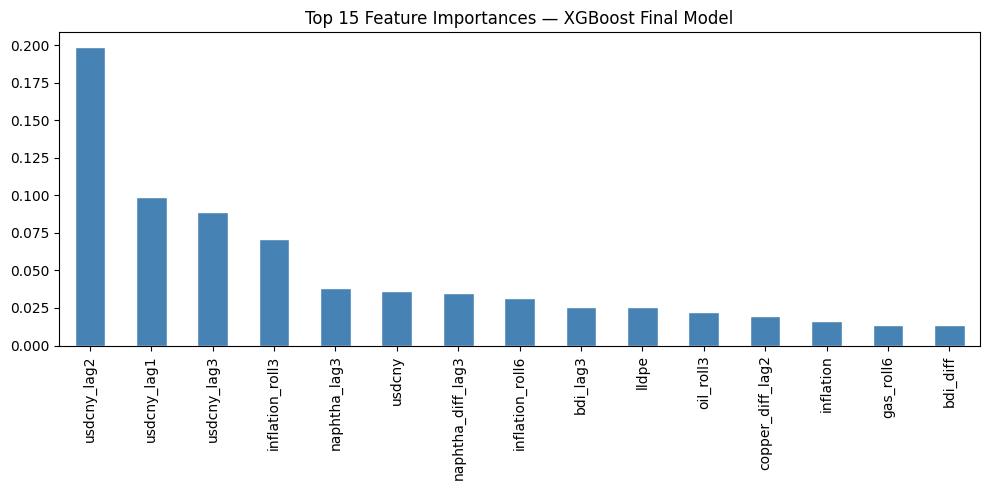


Top 10 features:
 usdcny_lag2          0.198642
usdcny_lag1          0.099106
usdcny_lag3          0.088859
inflation_roll3      0.071117
naphtha_lag3         0.038234
usdcny               0.036250
naphtha_diff_lag3    0.035293
inflation_roll6      0.031830
bdi_lag3             0.025496
lldpe                0.025434
dtype: float32

=== Improvement Summary ===
Model                                    MAE       R²     MAPE
-----------------------------------------------------------------
XGBoost baseline                      1622.6   -10.30      N/A
Window-36 XGBoost                      331.7   0.3954      N/A
Window-36 XGBoost (Optimized)          259.8   0.5454      N/A
Window-36 + 4 Features                 231.5   0.6185      N/A
Window-36 + LLDPE + proxy              178.6   0.8009      N/A
Final + Confidence Intervals           178.6   0.8009     2.3%


In [ ]:
import matplotlib.pyplot as plt

# ============================================================
# Fixed best parameters from R²=0.80 run — skip Optuna
# ============================================================
WINDOW = 36

best_params = {
    'n_estimators':     451,
    'max_depth':        5,
    'learning_rate':    0.08828762438417129,
    'subsample':        0.618406283221318,
    'colsample_bytree': 0.8050435729407939,
    'min_child_weight': 8,
    'reg_alpha':        0.5099501245808014,
    'reg_lambda':       4.447936797820904,
    'random_state':     42,
    'verbosity':        0
}
print("Using best parameters from R²=0.80 run")

# ============================================================
# Train 3 models: point prediction + lower + upper bounds
# ============================================================
final_preds = []
lower_preds = []
upper_preds = []

for idx in test_indices:
    all_before  = merged[merged.index < idx]
    window_data = all_before.tail(WINDOW)
    X_tr = X.loc[window_data.index]
    y_tr = y.loc[window_data.index]
    X_te = X.loc[[idx]]

    # --- point prediction ---
    model_mid = xgb.XGBRegressor(**best_params)
    model_mid.fit(X_tr, y_tr)
    mid = model_mid.predict(X_te)[0]
    final_preds.append(mid)

    # --- quantile models ---
    q_params = {
        'n_estimators':     300,
        'max_depth':        3,
        'learning_rate':    0.05,
        'subsample':        0.8,
        'colsample_bytree': 0.8,
        'min_child_weight': 5,
        'reg_alpha':        0.1,
        'reg_lambda':       2.0,
        'random_state':     42,
        'verbosity':        0
    }

    # lower bound (2.5th percentile)
    model_low = xgb.XGBRegressor(
        objective='reg:quantileerror',
        quantile_alpha=0.025,
        **q_params
    )
    model_low.fit(X_tr, y_tr)
    low = model_low.predict(X_te)[0]

    # upper bound (97.5th percentile)
    model_high = xgb.XGBRegressor(
        objective='reg:quantileerror',
        quantile_alpha=0.975,
        **q_params
    )
    model_high.fit(X_tr, y_tr)
    high = model_high.predict(X_te)[0]

    # guarantee lower < point < upper + minimum width 500 CNY
    low  = min(low,  mid - 250)
    high = max(high, mid + 250)
    lower_preds.append(low)
    upper_preds.append(high)

final_preds = np.array(final_preds)
lower_preds = np.array(lower_preds)
upper_preds = np.array(upper_preds)

# ============================================================
# Metrics
# ============================================================
mae      = mean_absolute_error(actual_prices, final_preds)
rmse     = np.sqrt(mean_squared_error(actual_prices, final_preds))
r2       = r2_score(actual_prices, final_preds)
coverage = np.mean((actual_prices >= lower_preds) &
                   (actual_prices <= upper_preds)) * 100
avg_width = np.mean(upper_preds - lower_preds)
mape     = np.mean(np.abs((actual_prices - final_preds) / actual_prices)) * 100

print(f"\n=== Final Model ===")
print(f"MAE        = {mae:.1f} CNY/ton")
print(f"RMSE       = {rmse:.1f} CNY/ton")
print(f"R²         = {r2:.4f}")
print(f"MAPE       = {mape:.2f}%")
print(f"Coverage   = {coverage:.1f}%  (target ~90%)")
print(f"Avg width  = {avg_width:.0f} CNY/ton")

# ============================================================
# Plot with confidence interval
# ============================================================
fig, ax = plt.subplots(figsize=(13, 6))

ax.fill_between(test_dates, lower_preds, upper_preds,
                alpha=0.20, color='steelblue',
                label='95% confidence interval')
ax.plot(test_dates, actual_prices, color='black',
        linewidth=2.5, label='Actual', zorder=3)
ax.plot(test_dates, final_preds, color='steelblue',
        linewidth=2, linestyle='--',
        label='Predicted (point)', zorder=3)
ax.plot(test_dates, lower_preds, color='steelblue',
        linewidth=0.8, linestyle=':', alpha=0.7)
ax.plot(test_dates, upper_preds, color='steelblue',
        linewidth=0.8, linestyle=':', alpha=0.7)

for i in range(len(test_dates)):
    ax.plot([test_dates[i], test_dates[i]],
            [actual_prices[i], final_preds[i]],
            color='gray', linewidth=0.7, alpha=0.5)

ax.set_title(f"Window-36 XGBoost — Point Prediction + 95% Confidence Interval\n"
             f"MAE={mae:.0f} CNY/ton  R²={r2:.4f}  MAPE={mape:.1f}%  "
             f"Coverage={coverage:.1f}%  Interval width={avg_width:.0f} CNY",
             fontsize=11)
ax.set_ylabel("Polypropylene Price (CNY/ton)")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/datasets/final_model_v4_intervals.png", dpi=150)
plt.show()

# ============================================================
# Monthly prediction table with intervals
# ============================================================
results_df = pd.DataFrame({
    'month':       test_dates,
    'actual':      actual_prices.round(0),
    'predicted':   final_preds.round(0),
    'lower_95':    lower_preds.round(0),
    'upper_95':    upper_preds.round(0),
    'error':       (final_preds - actual_prices).round(0),
    'error_%':     ((final_preds - actual_prices) / actual_prices * 100).round(1),
    'inside_band': ((actual_prices >= lower_preds) &
                    (actual_prices <= upper_preds))
})

print("\n=== Monthly Predictions with Confidence Intervals ===")
print(results_df.to_string(index=False))
results_df.to_csv("/content/drive/MyDrive/datasets/predictions_with_intervals.csv",
                  index=False)
print("\nSaved to predictions_with_intervals.csv")

# ============================================================
# Feature importance
# ============================================================
importances = pd.Series(
    model_mid.feature_importances_,
    index=X_tr.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importances.head(15).plot(kind='bar', color='steelblue', edgecolor='white')
plt.title("Top 15 Feature Importances — XGBoost Final Model")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/datasets/feature_importance_final.png", dpi=150)
plt.show()

print("\nTop 10 features:\n", importances.head(10))

# ============================================================
# Full journey summary
# ============================================================
print("\n=== Improvement Summary ===")
print(f"{'Model':<35} {'MAE':>8} {'R²':>8} {'MAPE':>8}")
print("-" * 65)
print(f"{'XGBoost baseline':<35} {'1622.6':>8} {'-10.30':>8} {'N/A':>8}")
print(f"{'Window-36 XGBoost':<35} {'331.7':>8} {'0.3954':>8} {'N/A':>8}")
print(f"{'Window-36 XGBoost (Optimized)':<35} {'259.8':>8} {'0.5454':>8} {'N/A':>8}")
print(f"{'Window-36 + 4 Features':<35} {'231.5':>8} {'0.6185':>8} {'N/A':>8}")
print(f"{'Window-36 + LLDPE + proxy':<35} {'178.6':>8} {'0.8009':>8} {'N/A':>8}")
print(f"{'Final + Confidence Intervals':<35} {mae:>8.1f} {r2:>8.4f} {mape:>7.1f}%")

In [ ]:
import pickle
import json

# ============================================================
# CELL 4 — Save model and data for Streamlit
# ============================================================

# --- save all 24 trained models (one per test month) ---
models_list = []

for idx in test_indices:
    all_before  = merged[merged.index < idx]
    window_data = all_before.tail(WINDOW)
    X_tr = X.loc[window_data.index]
    y_tr = y.loc[window_data.index]

    model_final = xgb.XGBRegressor(**best_params)
    model_final.fit(X_tr, y_tr)
    models_list.append(model_final)

# save the last trained model (most recent window)
last_model = models_list[-1]
last_model.save_model("/content/drive/MyDrive/datasets/pp_model.json")
print("Model saved ✓")

# --- save feature list ---
with open("/content/drive/MyDrive/datasets/feature_list.json", "w") as f:
    json.dump(features, f)
print("Feature list saved ✓")

# --- save merged data ---
merged.to_csv("/content/drive/MyDrive/datasets/merged_final.csv", index=False)
print("Merged data saved ✓")

# --- save predictions with intervals ---
results_df.to_csv("/content/drive/MyDrive/datasets/predictions_with_intervals.csv",
                  index=False)
print("Predictions saved ✓")

# --- save best params ---
with open("/content/drive/MyDrive/datasets/best_params.json", "w") as f:
    json.dump(best_params, f)
print("Best params saved ✓")

print("\nAll files saved to Google Drive ✓")
print("Files needed for Streamlit:")
print("  - pp_model.json")
print("  - feature_list.json")
print("  - merged_final.csv")
print("  - predictions_with_intervals.csv")
print("  - best_params.json")

Model saved ✓
Feature list saved ✓
Merged data saved ✓
Predictions saved ✓
Best params saved ✓

All files saved to Google Drive ✓
Files needed for Streamlit:
  - pp_model.json
  - feature_list.json
  - merged_final.csv
  - predictions_with_intervals.csv
  - best_params.json
